# 📰 Text Mining: Eksplorasi Data Berita Indonesia
### Klasifikasi Sumber Berita: Kompas | Detik | Tempo

---
> **Tujuan:** Menemukan pola linguistik pada teks berita untuk mengidentifikasi sumber (label) asal berita.

**Tahapan notebook ini:**
1. Load & Inspeksi Dataset
2. Distribusi Label (Source)
3. Analisis Panjang Teks
4. Preprocessing Teks (Cleaning, Stopword, Stemming)
5. Analisis Frekuensi Kata (Global & Per Label)
6. Word Cloud per Label
7. TF-IDF Analysis — Kata Paling Diskriminatif per Label
8. N-Gram Analysis (Bigram & Trigram)
9. Insight & Rekomendasi Strategi

---
## 1. Setup & Import Library

In [17]:
# Core Libraries
import pandas as pd
import numpy as np
import re
import string
import warnings
warnings.filterwarnings('ignore')

# Visualisasi
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
from wordcloud import WordCloud, STOPWORDS
from collections import Counter

# NLP
import nltk
from nltk.corpus import stopwords
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer

# Download NLTK data
nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)

# Style
plt.rcParams.update({
    'figure.facecolor': '#0f0f1a',
    'axes.facecolor':   '#1a1a2e',
    'axes.edgecolor':   '#444466',
    'axes.labelcolor':  '#e0e0ff',
    'xtick.color':      '#e0e0ff',
    'ytick.color':      '#e0e0ff',
    'text.color':       '#e0e0ff',
    'grid.color':       '#2a2a4a',
    'grid.linewidth':   0.5,
    'font.family':      'DejaVu Sans',
    'font.size':        11,
})

# Palet warna per label
LABEL_COLORS = {
    'kompas': '#6C63FF',   # Ungu
    'tempo':  '#FF6584',   # Merah muda
    'detik':  '#43D9AD',   # Hijau tosca
}

print('Semua library berhasil diimport.')

Semua library berhasil diimport.


---
## 2. Load & Inspeksi Dataset

In [18]:
df = pd.read_csv('final_merge_dataset.csv')

print(f'Shape dataset: {df.shape}')
print(f'Kolom: {df.columns.tolist()}')
display(df.head(3))

Shape dataset: (80472, 10)
Kolom: ['Judul', 'Waktu', 'Link', 'Content', 'tag1', 'tag2', 'tag3', 'tag4', 'tag5', 'source']


,Judul,Waktu,Link,Content,tag1,tag2,tag3,tag4,tag5,source
0,"Viral Isu PHK Buruh Gudang Garam, Said Iqbal: ...",6 September 2025,https://nasional.kompas.com/read/2025/09/06/14...,"JAKARTA, KOMPAS.com – Presiden Konfederasi Se...",Said Iqbal,industri rokok,PT Gudang Garam,PHK massal,phk massal 2025 terbaru,kompas
1,"Gempa M 5,3 Guncang Pulau Doi Maluku Utara","Senin, 12 Agu 2024 21:58 WIB",https://news.detik.com/berita/d-7486691/gempa-...,"Gempa bumi berkekuatan magnitudo (M) 5,3 mengg...",pulau doi,gempa,NaN,NaN,NaN,detik
2,"Toko Emas Palsu di Riau Dibongkar Polisi, Perh...","Rabu, 30 Jul 2025 22:22 WIB",https://news.detik.com/melindungi-tuah-marwah/...,Satreskrim Polres Bengkalis membongkar praktik...,pemalsuan emas,emas palsu,polres bengkalis,polda riau,melindungi tuah marwah,detik


In [19]:
print('=== INFO DATASET ===')
df.info()

print('\n=== MISSING VALUES ===')
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
display(missing_df[missing_df['Missing Count'] > 0])

print('\n=== STATISTIK DESKRIPTIF KOLOM TEKS ===')
df['content_len'] = df['Content'].fillna('').apply(len)
df['judul_len']   = df['Judul'].fillna('').apply(len)
display(df[['content_len', 'judul_len']].describe())

=== INFO DATASET ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 80472 entries, 0 to 80471
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   Judul    80472 non-null  object
 1   Waktu    80472 non-null  object
 2   Link     80472 non-null  object
 3   Content  80463 non-null  object
 4   tag1     78023 non-null  object
 5   tag2     77612 non-null  object
 6   tag3     71602 non-null  object
 7   tag4     56856 non-null  object
 8   tag5     35633 non-null  object
 9   source   80472 non-null  object
dtypes: object(10)
memory usage: 6.1+ MB

=== MISSING VALUES ===


,Missing Count,Missing %
Content,9,0.01
tag1,2449,3.04
tag2,2860,3.55
tag3,8870,11.02
tag4,23616,29.35
tag5,44839,55.72



=== STATISTIK DESKRIPTIF KOLOM TEKS ===


,content_len,judul_len
count,80472.000000,80472.000000
mean,2397.042723,69.228800
std,1162.876148,13.679882
min,0.000000,5.000000
25%,1707.000000,61.000000
50%,2225.000000,70.000000
75%,2822.000000,77.000000
max,37293.000000,188.000000


---
## 3. Distribusi Label (Source)

=== DISTRIBUSI LABEL ===


,Jumlah,Persentase (%)
source,,
kompas,35449,44.05
tempo,25633,31.85
detik,19390,24.10


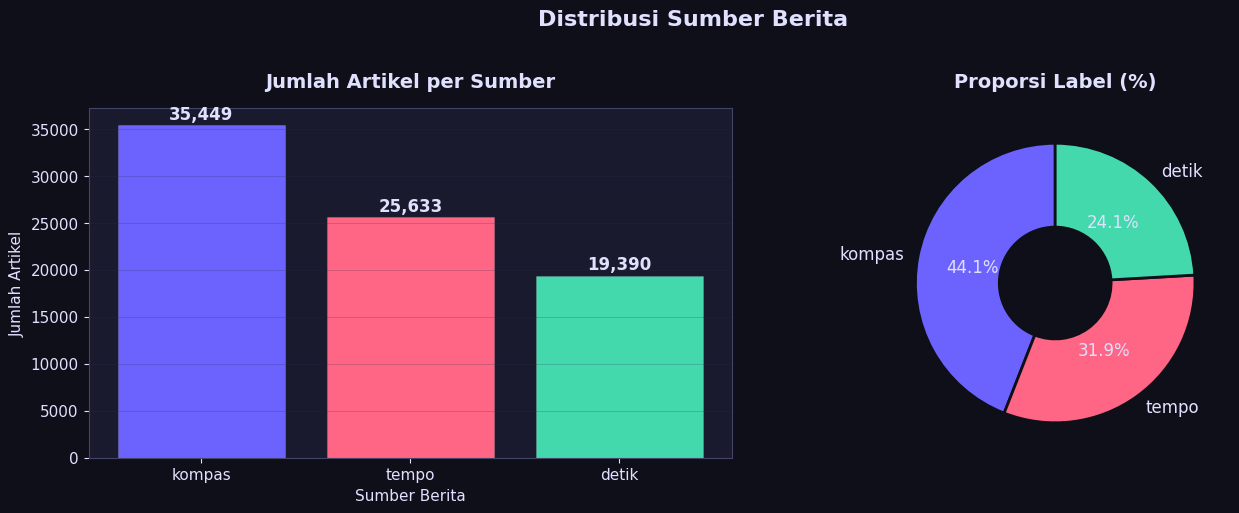


Imbalance ratio (max/min): 1.83x


In [20]:
label_counts = df['source'].value_counts()
label_pct    = (label_counts / len(df) * 100).round(2)

print('=== DISTRIBUSI LABEL ===')
dist_df = pd.DataFrame({'Jumlah': label_counts, 'Persentase (%)': label_pct})
display(dist_df)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor('#0f0f1a')

# Bar chart
colors = [LABEL_COLORS[l] for l in label_counts.index]
bars = axes[0].bar(label_counts.index, label_counts.values, color=colors,
                   edgecolor='#ffffff22', linewidth=0.8)
for bar, val in zip(bars, label_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
                 f'{val:,}', ha='center', va='bottom', fontsize=12, fontweight='bold')
axes[0].set_title('Jumlah Artikel per Sumber', fontsize=14, fontweight='bold', pad=15)
axes[0].set_xlabel('Sumber Berita')
axes[0].set_ylabel('Jumlah Artikel')
axes[0].grid(axis='y', alpha=0.3)
axes[0].set_facecolor('#1a1a2e')

# Pie chart
wedge_props = dict(width=0.6, edgecolor='#0f0f1a', linewidth=2)
axes[1].pie(
    label_counts.values, labels=label_counts.index,
    autopct='%1.1f%%', colors=colors,
    wedgeprops=wedge_props, startangle=90,
    textprops={'color': '#e0e0ff', 'fontsize': 12}
)
axes[1].set_title('Proporsi Label (%)', fontsize=14, fontweight='bold', pad=15)
axes[1].set_facecolor('#1a1a2e')

plt.suptitle('Distribusi Sumber Berita', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()
print(f'\nImbalance ratio (max/min): {label_counts.max() / label_counts.min():.2f}x')

---
## 4. Analisis Panjang Teks per Label

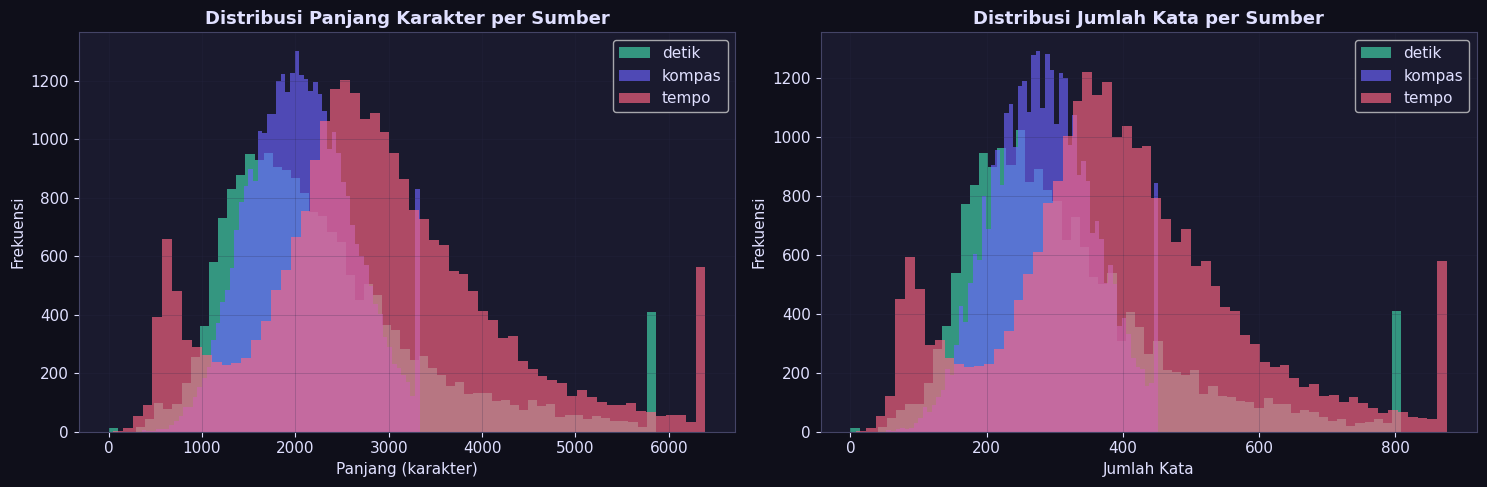


=== STATISTIK PANJANG TEKS PER LABEL ===


content_len                             word_count                    \
              mean  median     std  min    max       mean median    std min   
source                                                                        
detik       2351.9  2058.0  1400.6    0  37293      323.0  282.0  193.1   0   
kompas      2077.4  2047.0   595.4  354  30426      285.8  283.0   80.3  53   
tempo       2873.2  2752.0  1379.0   47  35904      398.2  382.0  189.4   8   

              
         max  
source        
detik   5676  
kompas  3985  
tempo   4784

In [21]:
df['word_count'] = df['Content'].fillna('').apply(lambda x: len(x.split()))

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.patch.set_facecolor('#0f0f1a')

for ax, col, title, xlabel in zip(
    axes,
    ['content_len', 'word_count'],
    ['Distribusi Panjang Karakter per Sumber', 'Distribusi Jumlah Kata per Sumber'],
    ['Panjang (karakter)', 'Jumlah Kata']
):
    for label, grp in df.groupby('source'):
        ax.hist(grp[col].clip(upper=grp[col].quantile(0.98)), bins=60,
                alpha=0.65, label=label, color=LABEL_COLORS[label],
                edgecolor='none')
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xlabel(xlabel)
    ax.set_ylabel('Frekuensi')
    ax.legend()
    ax.grid(alpha=0.3)
    ax.set_facecolor('#1a1a2e')

plt.tight_layout()
plt.show()

print('\n=== STATISTIK PANJANG TEKS PER LABEL ===')
display(df.groupby('source')[['content_len', 'word_count']]
          .agg(['mean', 'median', 'std', 'min', 'max'])
          .round(1))

---
## 5. Preprocessing Teks

In [22]:
# Inisialisasi Stemmer Bahasa Indonesia (Sastrawi)
factory = StemmerFactory()
stemmer = factory.create_stemmer()

# Stopwords Bahasa Indonesia + Inggris
sw_id = set(stopwords.words('indonesian'))
sw_en = set(stopwords.words('english'))

# Tambahan stopwords domain berita
custom_sw = {
    'jakarta', 'juga', 'ini', 'itu', 'yang', 'dan', 'di', 'ke', 'dari',
    'dengan', 'untuk', 'pada', 'tidak', 'adalah', 'sudah', 'telah',
    'akan', 'ada', 'oleh', 'kami', 'mereka', 'kita', 'saya', 'anda',
    'kompascom', 'tempo', 'detikcom', 'detik', 'kompas', 'com',
    'baca', 'artikel', 'halaman', 'berikut', 'selanjutnya', 'lihat',
    'foto', 'video', 'baca juga', 'simak', 'republika', 'cnbc',
    'liputan', 'tribun', 'media', 'online', 'news', 'id', 'http',
    'https', 'www', 'co', 'go', 'org', 'net'
}
ALL_STOPWORDS = sw_id | sw_en | custom_sw

def preprocess(text, use_stemming=False):
    """Pipeline preprocessing lengkap."""
    if not isinstance(text, str):
        return ''
    # Lowercase
    text = text.lower()
    # Hapus URL
    text = re.sub(r'http\S+|www\.\S+', '', text)
    # Hapus karakter non-ASCII & encoding error (misal â€)
    text = text.encode('ascii', 'ignore').decode('ascii')
    # Hapus angka
    text = re.sub(r'\d+', '', text)
    # Hapus tanda baca & karakter khusus
    text = re.sub(r'[^\w\s]', ' ', text)
    # Hapus underscore
    text = text.replace('_', ' ')
    # Tokenisasi & hapus stopwords
    tokens = [t for t in text.split() if t not in ALL_STOPWORDS and len(t) > 2]
    # Stemming (opsional — lebih lambat)
    if use_stemming:
        tokens = [stemmer.stem(t) for t in tokens]
    return ' '.join(tokens)

print('Menjalankan preprocessing (tanpa stemming untuk EDA cepat)...')
# Gunakan Judul + Content digabung sebagai teks utama
df['text_combined'] = df['Judul'].fillna('') + ' ' + df['Content'].fillna('')
df['text_clean']    = df['text_combined'].apply(preprocess)
df['clean_word_count'] = df['text_clean'].apply(lambda x: len(x.split()))

print('Preprocessing selesai!')
print(f'\nContoh asli    : {df["text_combined"].iloc[0][:200]}')
print(f'Contoh bersih  : {df["text_clean"].iloc[0][:200]}')

Menjalankan preprocessing (tanpa stemming untuk EDA cepat)...
Preprocessing selesai!

Contoh asli    : Viral Isu PHK Buruh Gudang Garam, Said Iqbal: Suplier hingga Pemilik Kontrakan Juga Akan Terdampak  JAKARTA, KOMPAS.com – Presiden Konfederasi Serikat Pekerja Indonesia (KSPI) Said Iqbal mengatakan, k
Contoh bersih  : viral isu phk buruh gudang garam said iqbal suplier pemilik kontrakan terdampak presiden konfederasi serikat pekerja indonesia kspi said iqbal kabar pemutusan hubungan kerja phk buruh pabrik rokok gud


---
## 6. Analisis Frekuensi Kata — Global & Per Label

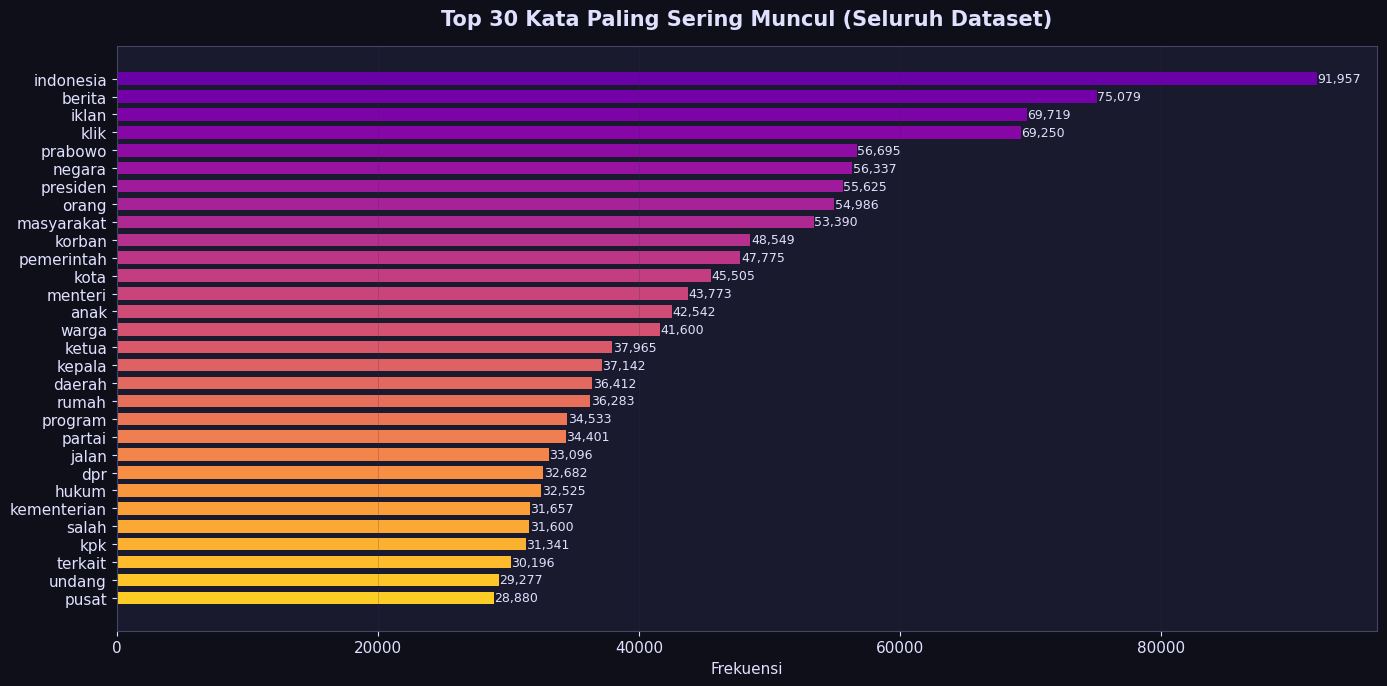

In [23]:
def get_top_words(corpus_series, n=30):
    """Hitung top-N kata dari kumpulan teks."""
    all_words = ' '.join(corpus_series).split()
    return Counter(all_words).most_common(n)

# Top 30 kata GLOBAL
top_global = get_top_words(df['text_clean'], n=30)
words_g, freqs_g = zip(*top_global)

fig, ax = plt.subplots(figsize=(14, 7))
fig.patch.set_facecolor('#0f0f1a')
ax.set_facecolor('#1a1a2e')

grad_colors = plt.cm.plasma(np.linspace(0.2, 0.9, len(words_g)))
bars = ax.barh(list(reversed(words_g)), list(reversed(freqs_g)),
               color=list(reversed(grad_colors)), edgecolor='none', height=0.7)
for bar, val in zip(bars, list(reversed(freqs_g))):
    ax.text(bar.get_width() + 50, bar.get_y() + bar.get_height()/2,
            f'{val:,}', va='center', fontsize=9)

ax.set_title('Top 30 Kata Paling Sering Muncul (Seluruh Dataset)', fontsize=15, fontweight='bold', pad=15)
ax.set_xlabel('Frekuensi')
ax.grid(axis='x', alpha=0.3)
ax.tick_params(axis='y', labelsize=11)

plt.tight_layout()
plt.show()

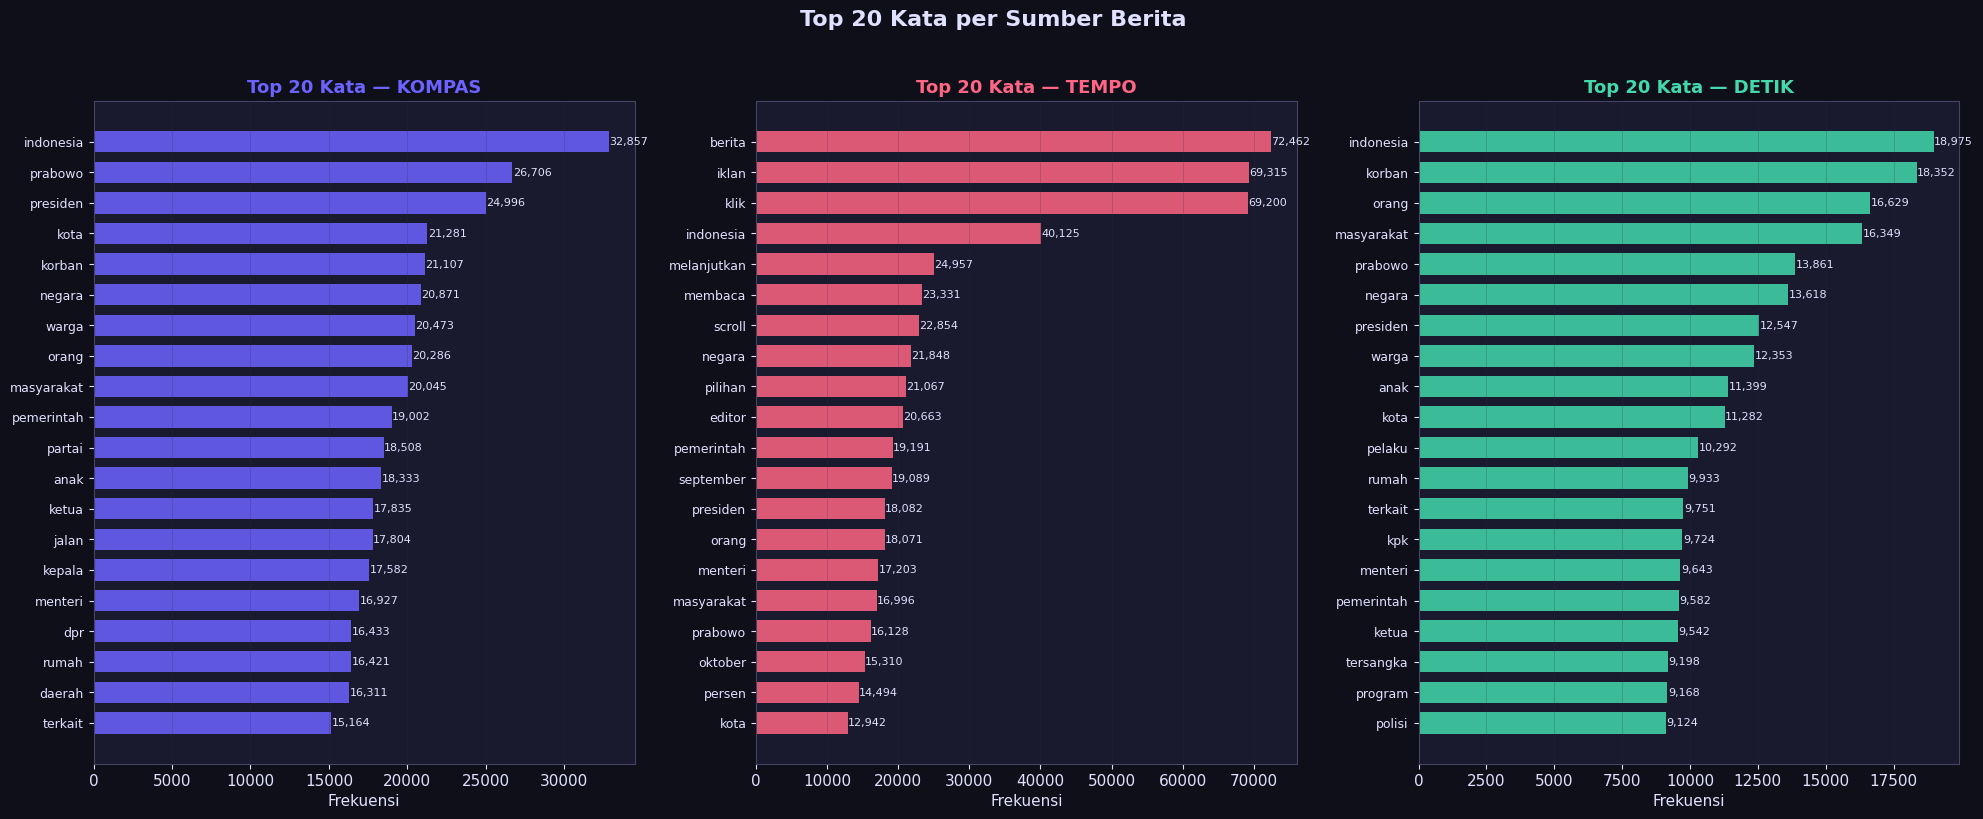

In [24]:
# Top 20 kata PER LABEL
labels = df['source'].unique()
fig, axes = plt.subplots(1, 3, figsize=(20, 8))
fig.patch.set_facecolor('#0f0f1a')

for ax, label in zip(axes, ['kompas', 'tempo', 'detik']):
    corpus = df[df['source'] == label]['text_clean']
    top_words = get_top_words(corpus, n=20)
    words, freqs = zip(*top_words)

    color = LABEL_COLORS[label]
    bars = ax.barh(list(reversed(words)), list(reversed(freqs)),
                   color=color, alpha=0.85, edgecolor='none', height=0.7)
    for bar, val in zip(bars, list(reversed(freqs))):
        ax.text(bar.get_width() + 20, bar.get_y() + bar.get_height()/2,
                f'{val:,}', va='center', fontsize=8)

    ax.set_title(f'Top 20 Kata — {label.upper()}',
                 fontsize=13, fontweight='bold', color=color)
    ax.set_facecolor('#1a1a2e')
    ax.grid(axis='x', alpha=0.3)
    ax.tick_params(axis='y', labelsize=9)
    ax.set_xlabel('Frekuensi')

plt.suptitle('Top 20 Kata per Sumber Berita', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---
## 7. Word Cloud per Label

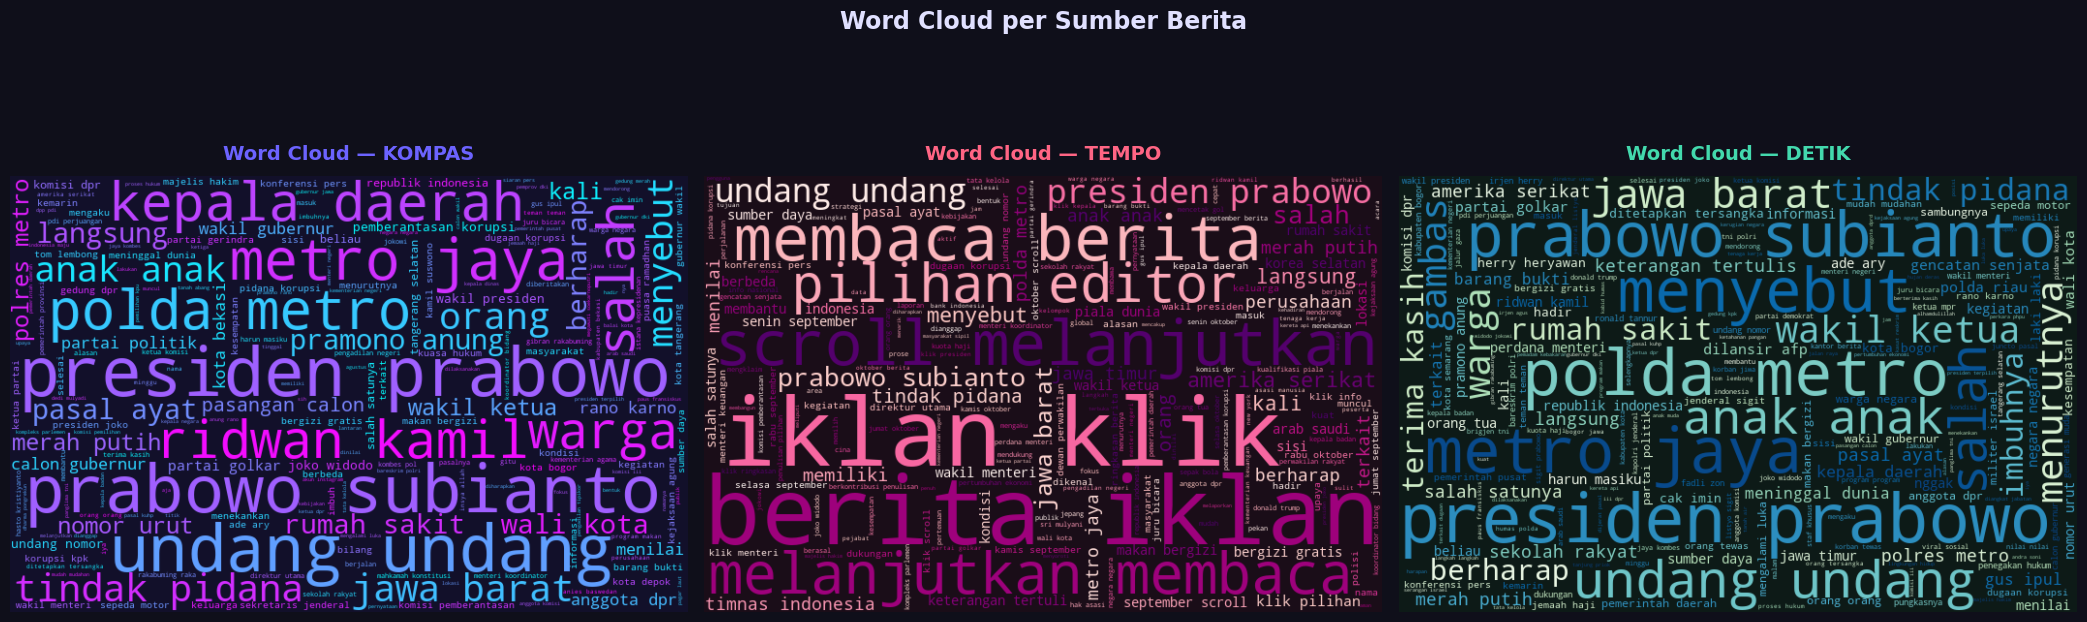

In [25]:
WC_BACKGROUNDS = {'kompas': '#12102a', 'tempo': '#1a0d18', 'detik': '#0d1a17'}
WC_COLORMAPS   = {'kompas': 'cool', 'tempo': 'RdPu', 'detik': 'GnBu'}

fig, axes = plt.subplots(1, 3, figsize=(21, 7))
fig.patch.set_facecolor('#0f0f1a')

for ax, label in zip(axes, ['kompas', 'tempo', 'detik']):
    corpus_text = ' '.join(df[df['source'] == label]['text_clean'])
    wc = WordCloud(
        width=700, height=450,
        background_color=WC_BACKGROUNDS[label],
        colormap=WC_COLORMAPS[label],
        max_words=200,
        prefer_horizontal=0.8,
        contour_color=LABEL_COLORS[label],
        contour_width=1
    ).generate(corpus_text)

    ax.imshow(wc, interpolation='bilinear')
    ax.axis('off')
    ax.set_title(f'Word Cloud — {label.upper()}',
                 fontsize=14, fontweight='bold',
                 color=LABEL_COLORS[label], pad=12)
    ax.set_facecolor(WC_BACKGROUNDS[label])

plt.suptitle('Word Cloud per Sumber Berita', fontsize=17, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---
## 8. TF-IDF — Kata Paling Diskriminatif per Label

Menghitung TF-IDF...
TF-IDF selesai!


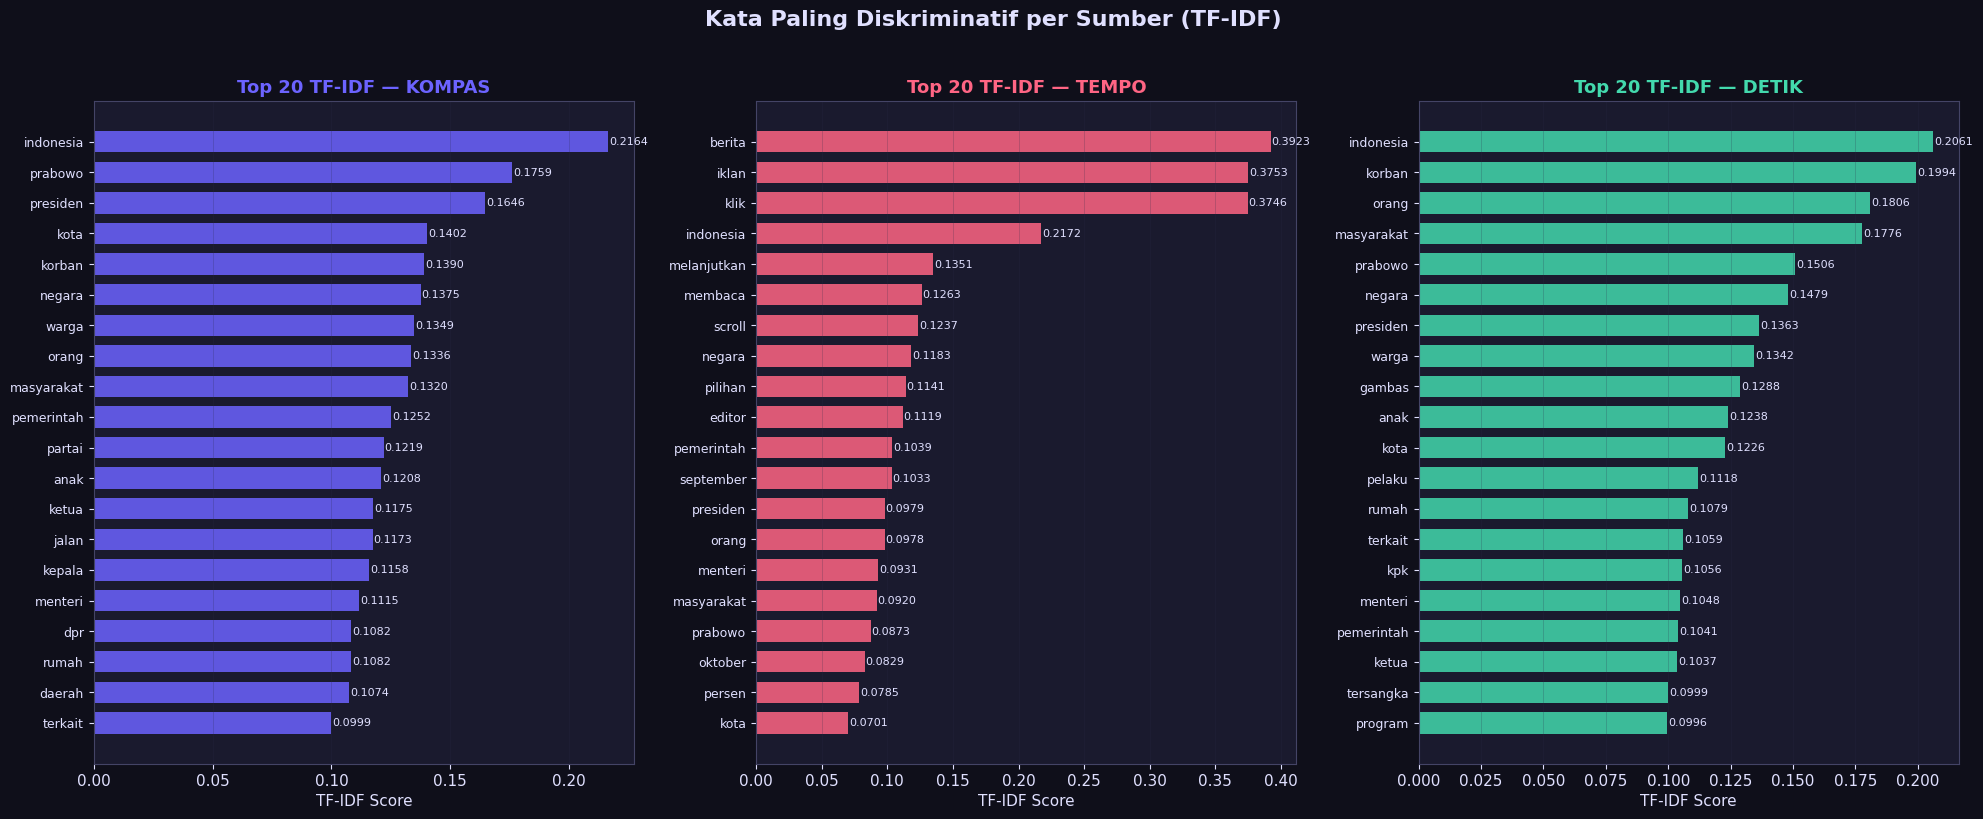

In [26]:
print('Menghitung TF-IDF...')

# Gabungkan semua teks per label (document = satu label)
label_corpus = {label: ' '.join(df[df['source'] == label]['text_clean'])
                for label in ['kompas', 'tempo', 'detik']}

# TF-IDF per-dokumen-label
tfidf_label = TfidfVectorizer(max_features=10000, ngram_range=(1, 1))
tfidf_matrix = tfidf_label.fit_transform(list(label_corpus.values()))
feature_names = tfidf_label.get_feature_names_out()

# Ambil top-20 TF-IDF per label
fig, axes = plt.subplots(1, 3, figsize=(20, 8))
fig.patch.set_facecolor('#0f0f1a')

for i, (label, ax) in enumerate(zip(['kompas', 'tempo', 'detik'], axes)):
    scores = tfidf_matrix[i].toarray().flatten()
    top_idx = scores.argsort()[::-1][:20]
    top_words = [feature_names[j] for j in top_idx]
    top_scores = [scores[j] for j in top_idx]

    color = LABEL_COLORS[label]
    bars = ax.barh(list(reversed(top_words)), list(reversed(top_scores)),
                   color=color, alpha=0.85, edgecolor='none', height=0.7)
    for bar, val in zip(bars, list(reversed(top_scores))):
        ax.text(bar.get_width() + 0.0005, bar.get_y() + bar.get_height()/2,
                f'{val:.4f}', va='center', fontsize=8)

    ax.set_title(f'Top 20 TF-IDF — {label.upper()}',
                 fontsize=13, fontweight='bold', color=color)
    ax.set_facecolor('#1a1a2e')
    ax.grid(axis='x', alpha=0.3)
    ax.tick_params(axis='y', labelsize=9)
    ax.set_xlabel('TF-IDF Score')

plt.suptitle('Kata Paling Diskriminatif per Sumber (TF-IDF)', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
print('TF-IDF selesai!')

---
## 9. N-Gram Analysis — Bigram & Trigram per Label

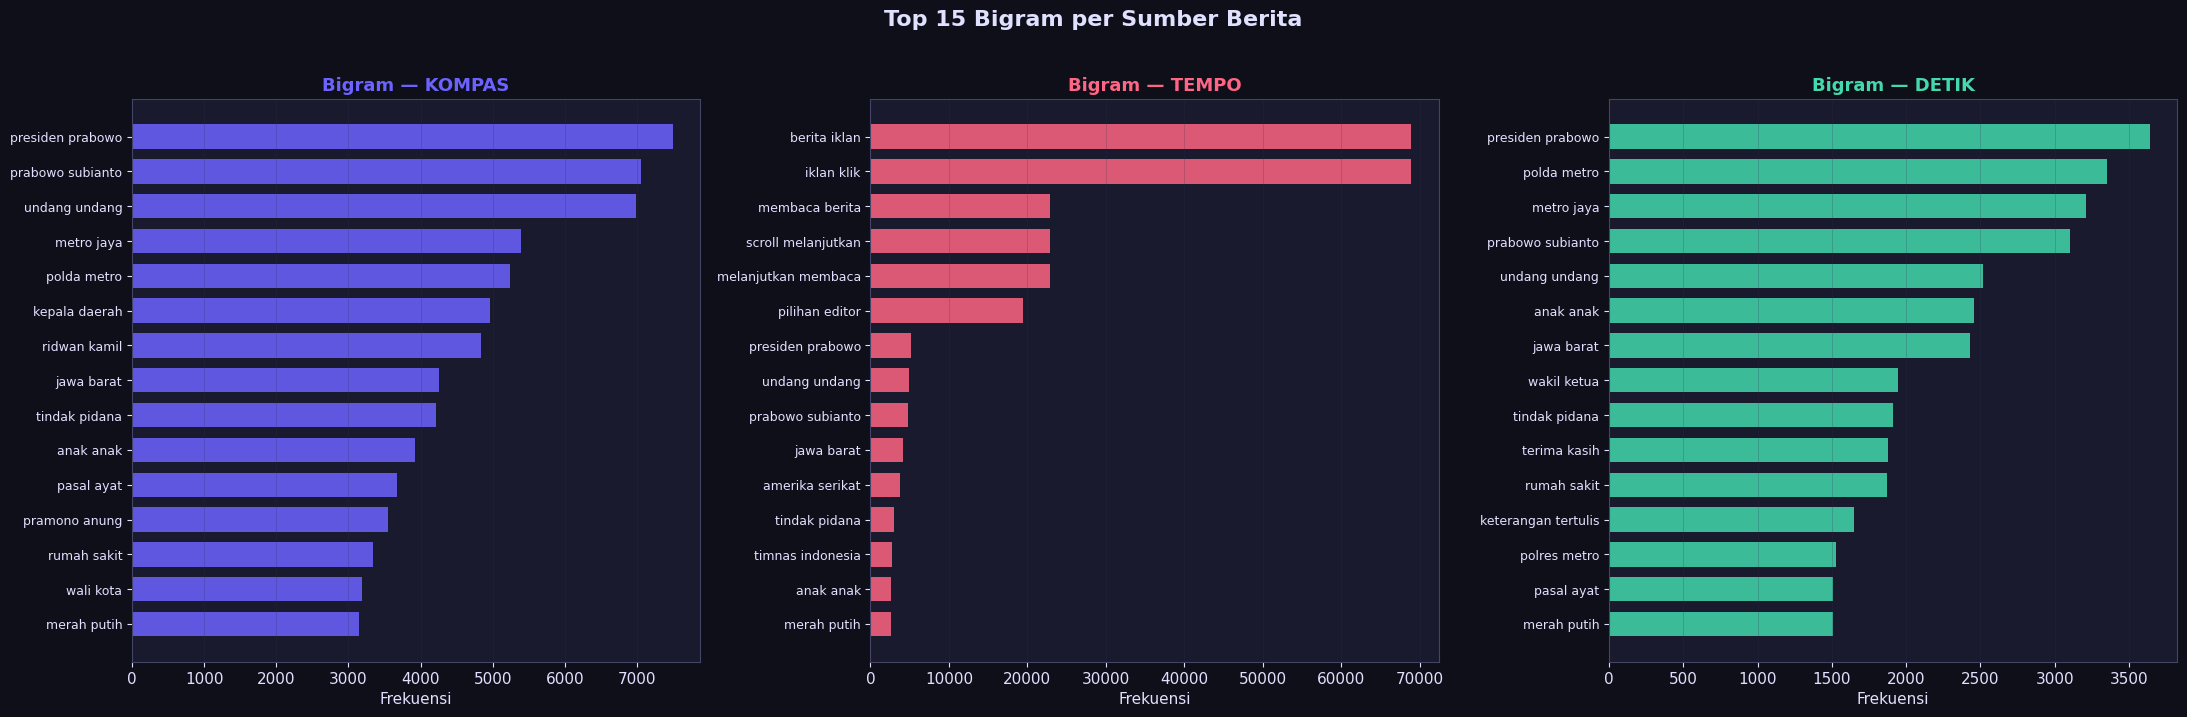

Bigram selesai!


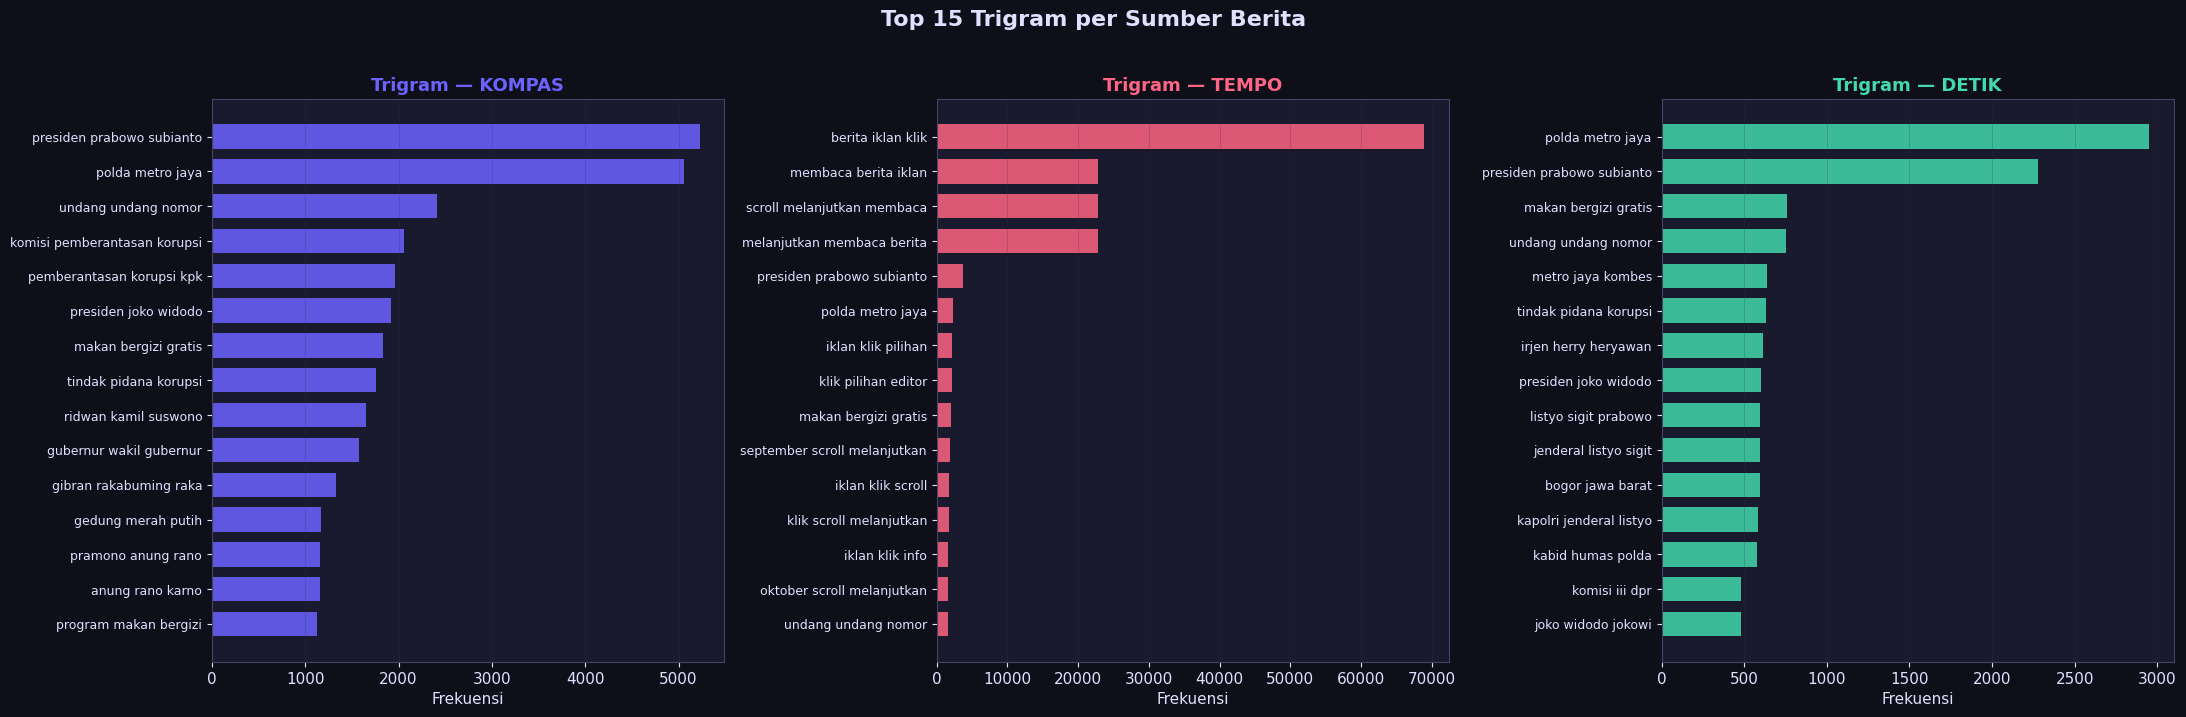

Trigram selesai!


In [27]:
def top_ngrams(corpus_series, n=2, top_k=15):
    """Ekstrak top-K n-gram dari sebuah corpus."""
    vec = CountVectorizer(ngram_range=(n, n), max_features=5000).fit(corpus_series)
    bag = vec.transform(corpus_series)
    sum_words = bag.sum(axis=0)
    words_freq = [(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()]
    return sorted(words_freq, key=lambda x: x[1], reverse=True)[:top_k]

for ng, ng_name in [(2, 'Bigram'), (3, 'Trigram')]:
    fig, axes = plt.subplots(1, 3, figsize=(22, 7))
    fig.patch.set_facecolor('#0f0f1a')

    for ax, label in zip(axes, ['kompas', 'tempo', 'detik']):
        corpus = df[df['source'] == label]['text_clean']
        ngrams = top_ngrams(corpus, n=ng, top_k=15)
        words, freqs = zip(*ngrams)

        color = LABEL_COLORS[label]
        ax.barh(list(reversed(words)), list(reversed(freqs)),
                color=color, alpha=0.85, edgecolor='none', height=0.7)
        ax.set_title(f'{ng_name} — {label.upper()}',
                     fontsize=13, fontweight='bold', color=color)
        ax.set_facecolor('#1a1a2e')
        ax.grid(axis='x', alpha=0.3)
        ax.tick_params(axis='y', labelsize=9)
        ax.set_xlabel('Frekuensi')

    plt.suptitle(f'Top 15 {ng_name} per Sumber Berita',
                 fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()
    print(f'{ng_name} selesai!')

---
## 10. Analisis Unique Vocabulary per Label

In [28]:
vocab_stats = {}
for label in ['kompas', 'tempo', 'detik']:
    all_words  = ' '.join(df[df['source'] == label]['text_clean']).split()
    unique_words = set(all_words)
    vocab_stats[label] = {
        'Total Kata (Token)': len(all_words),
        'Vocabulary Unik':    len(unique_words),
        'Type-Token Ratio':   round(len(unique_words) / len(all_words), 4)
    }

vocab_df = pd.DataFrame(vocab_stats).T
print('=== STATISTIK VOCABULARY PER LABEL ===')
display(vocab_df)

# Kata EKSKLUSIF (hanya ada di satu label)
print('\n=== KATA EKSKLUSIF (unik hanya di satu label) ===')
vocab_sets = {label: set(' '.join(df[df['source'] == label]['text_clean']).split())
              for label in ['kompas', 'tempo', 'detik']}

for label in ['kompas', 'tempo', 'detik']:
    others = set()
    for other_label, other_set in vocab_sets.items():
        if other_label != label:
            others |= other_set
    exclusive = vocab_sets[label] - others
    print(f'\n{label.upper()} — {len(exclusive):,} kata eksklusif')
    # Top 20 kata eksklusif berdasarkan frekuensi
    all_w = ' '.join(df[df['source'] == label]['text_clean']).split()
    exc_counts = Counter(w for w in all_w if w in exclusive)
    print('   Top 20:', exc_counts.most_common(20))

=== STATISTIK VOCABULARY PER LABEL ===


,Total Kata (Token),Vocabulary Unik,Type-Token Ratio
kompas,5881170.0,79468.0,0.0135
tempo,6054035.0,121026.0,0.0200
detik,3712565.0,47797.0,0.0129



=== KATA EKSKLUSIF (unik hanya di satu label) ===

KOMPAS — 27,653 kata eksklusif
   Top 20: [('imsak', 584), ('imsakiyah', 522), ('majmu', 200), ('shauma', 170), ('ghadin', 170), ('adaai', 170), ('fardhi', 170), ('ramadhaana', 170), ('hadzihis', 170), ('sanati', 170), ('lillaahi', 170), ('aalaa', 170), ('biskita', 146), ('bersahurlah', 100), ('perinci', 99), ('akhdi', 73), ('malapraktik', 73), ('dsk', 73), ('yulza', 61), ('tribunjakarta', 61)]

TEMPO — 67,945 kata eksklusif
   Top 20: [('videographer', 765), ('balindra', 746), ('ridian', 362), ('tottenham', 355), ('newcastle', 329), ('amston', 306), ('probel', 306), ('persita', 296), ('juventus', 257), ('amorim', 244), ('emailprotected', 235), ('atletico', 233), ('napoli', 231), ('epriyadi', 231), ('assist', 216), ('aprillio', 206), ('bojan', 205), ('mbappe', 202), ('hotspur', 193), ('janice', 189)]

DETIK — 8,979 kata eksklusif
   Top 20: [('gambas', 7002), ('detikjateng', 399), ('detikjatim', 371), ('detikjabar', 220), ('detiksumut

---
## 11. Heatmap Frekuensi Kata Top-30 antar Label

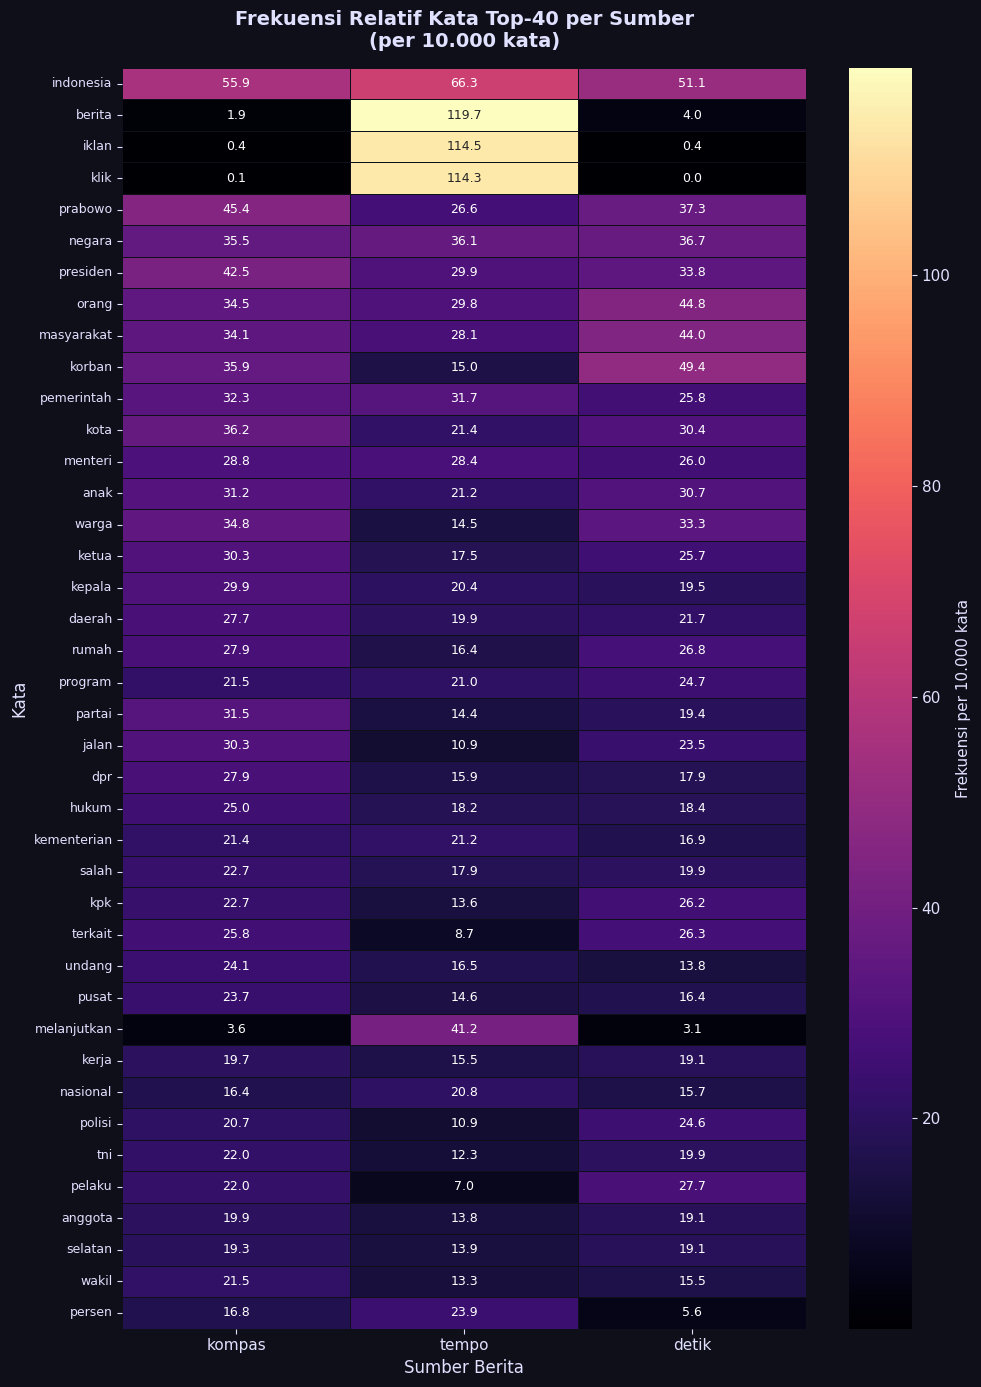

In [29]:
# Ambil top-40 kata global lalu hitung frekuensinya per label
top40_global = [w for w, _ in get_top_words(df['text_clean'], n=40)]

heat_data = {}
for label in ['kompas', 'tempo', 'detik']:
    wfreq = Counter(' '.join(df[df['source'] == label]['text_clean']).split())
    total = sum(wfreq.values())
    heat_data[label] = [wfreq.get(w, 0) / total * 10000 for w in top40_global]  # per 10k kata

heat_df = pd.DataFrame(heat_data, index=top40_global)

fig, ax = plt.subplots(figsize=(10, 14))
fig.patch.set_facecolor('#0f0f1a')
ax.set_facecolor('#1a1a2e')

sns.heatmap(heat_df, ax=ax, cmap='magma',
            linewidths=0.4, linecolor='#0f0f1a',
            annot=True, fmt='.1f', annot_kws={'size': 9},
            cbar_kws={'label': 'Frekuensi per 10.000 kata'})

ax.set_title('Frekuensi Relatif Kata Top-40 per Sumber\n(per 10.000 kata)',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Sumber Berita', fontsize=12)
ax.set_ylabel('Kata', fontsize=12)
ax.tick_params(axis='y', labelsize=9)

plt.tight_layout()
plt.show()

---
## 12. 📊 Ringkasan Insight & Rekomendasi Strategi

In [30]:
print("""
            RINGKASAN INSIGHT EKSPLORASI DATA
  DATASET
  Total artikel  : 80.472
  Label          : 3 (kompas, tempo, detik)
  Imbalance      : Kompas ~44%, Tempo ~32%, Detik ~24%
    Perlu strategi class weighting atau oversampling saat modelling
  TEKS
  Kompas   cenderung memiliki artikel lebih panjang
  Tempo    menggunakan gaya bahasa formal & analitis
  Detik    artikel lebih pendek & gaya bahasa kasual
  REKOMENDASI STRATEGI MODELLING
   Baseline  : TF-IDF + Naive Bayes / SVM / Decision Tree
    Cepat, interpretable, cocok sebagai benchmark
   Lanjutan  : TF-IDF dengan n-gram (1,3) + SVM (kernel linear)
    SVM terbukti terbaik untuk klasifikasi teks
   Advanced  : IndoBERT / indobenchmark/indobert-base-p1
     Contextual embedding, tangkap nuansa semantik lebih baik
  PREPROCESSING
  Stemming Sastrawi: penting untuk Bahasa Indonesia
  Stopwords combined (ID + EN) + domain-specific sangat diperlukan
  Pertimbangkan menggabungkan Judul + Content
  EVALUASI YANG DIREKOMENDASIKAN
  Macro F1-Score (karena kelas imbalance)
  Confusion Matrix
  Feature Importance / SHAP untuk interpretabilitas
""")


            RINGKASAN INSIGHT EKSPLORASI DATA
  DATASET
  Total artikel  : 80.472
  Label          : 3 (kompas, tempo, detik)
  Imbalance      : Kompas ~44%, Tempo ~32%, Detik ~24%
    Perlu strategi class weighting atau oversampling saat modelling
  TEKS
  Kompas   cenderung memiliki artikel lebih panjang
  Tempo    menggunakan gaya bahasa formal & analitis
  Detik    artikel lebih pendek & gaya bahasa kasual
  REKOMENDASI STRATEGI MODELLING
   Baseline  : TF-IDF + Naive Bayes / SVM / Decision Tree
    Cepat, interpretable, cocok sebagai benchmark
   Lanjutan  : TF-IDF dengan n-gram (1,3) + SVM (kernel linear)
    SVM terbukti terbaik untuk klasifikasi teks
   Advanced  : IndoBERT / indobenchmark/indobert-base-p1
     Contextual embedding, tangkap nuansa semantik lebih baik
  PREPROCESSING
  Stemming Sastrawi: penting untuk Bahasa Indonesia
  Stopwords combined (ID + EN) + domain-specific sangat diperlukan
  Pertimbangkan menggabungkan Judul + Content
  EVALUASI YANG DIREKOMENDASIKAN

In [31]:
# Tabel ringkasan dataset
summary_data = {
    'Sumber': ['kompas', 'tempo', 'detik', 'TOTAL'],
    'Jumlah Artikel': [
        int(df['source'].value_counts()['kompas']),
        int(df['source'].value_counts()['tempo']),
        int(df['source'].value_counts()['detik']),
        len(df)
    ],
    'Panjang Konten Rata-Rata (kata)': [
        round(df[df['source']=='kompas']['word_count'].mean()),
        round(df[df['source']=='tempo']['word_count'].mean()),
        round(df[df['source']=='detik']['word_count'].mean()),
        round(df['word_count'].mean())
    ],
    'Proporsi (%)': [
        round(df['source'].value_counts()['kompas'] / len(df) * 100, 1),
        round(df['source'].value_counts()['tempo']  / len(df) * 100, 1),
        round(df['source'].value_counts()['detik']  / len(df) * 100, 1),
        100.0
    ]
}

summary_df = pd.DataFrame(summary_data)
print('=== TABEL RINGKASAN DATASET ===')
display(summary_df)

print('\nEksplorasi data selesai! Semua visualisasi telah disimpan.')
print('File yang dihasilkan:')
import glob
for f in sorted(glob.glob('*.png')):
    print(f'   {f}')

=== TABEL RINGKASAN DATASET ===


,Sumber,Jumlah Artikel,Panjang Konten Rata-Rata (kata),Proporsi (%)
0,kompas,35449,286,44.1
1,tempo,25633,398,31.9
2,detik,19390,323,24.1
3,TOTAL,80472,331,100.0



Eksplorasi data selesai! Semua visualisasi telah disimpan.
File yang dihasilkan:


---
## 13. Hasil Pipeline — Load dari Disk
> Jalankan `run_pipeline.py` di terminal terlebih dahulu sebelum menjalankan sel-sel di bawah ini.
> ```powershell
> D:\Env\env\Scripts\python.exe run_pipeline.py
> ```

In [32]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import numpy as np

RESULTS_DIR = Path('results')

# Pastikan folder results tersedia
assert RESULTS_DIR.exists(), 'Folder results/ belum ada. Jalankan run_pipeline.py terlebih dahulu.'
print(f'Results folder: {RESULTS_DIR.resolve()}')
print('File tersedia:')
for f in sorted(RESULTS_DIR.iterdir()):
    print(f'  {f.name}')

Results folder: D:\Semester 6\text mining\results
File tersedia:
  baseline_results.csv
  cm_dt_nosmote.png
  cm_dt_smote.png
  cm_indobert.png
  cm_nb_nosmote.png
  cm_nb_smote.png
  cm_rf_nosmote.png
  cm_rf_smote.png
  cm_svm_nosmote.png
  cm_svm_smote.png
  indobert_learning_curve.png
  indobert_results.csv
  preprocessed_data.csv
  smote_distribution.png
  split_distribution.png


---
## 14. Distribusi Split Data

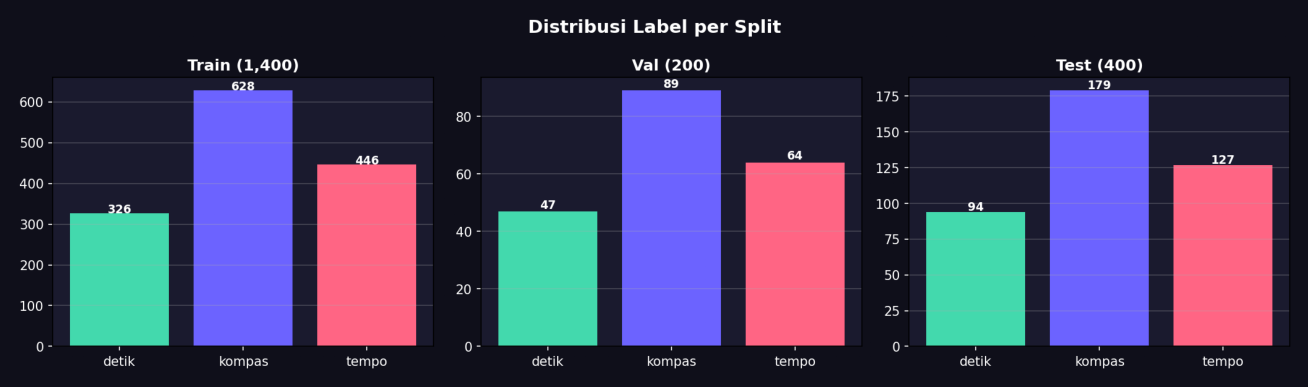

In [33]:
img = mpimg.imread(RESULTS_DIR / 'split_distribution.png')
plt.figure(figsize=(14, 4))
plt.imshow(img)
plt.axis('off')
plt.tight_layout()
plt.show()

---
## 15. Distribusi SMOTE

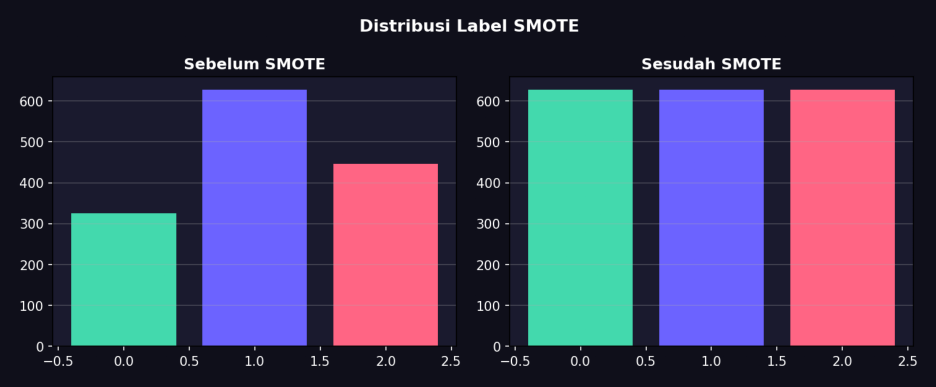

In [34]:
img = mpimg.imread(RESULTS_DIR / 'smote_distribution.png')
plt.figure(figsize=(10, 4))
plt.imshow(img)
plt.axis('off')
plt.tight_layout()
plt.show()

---
## 16. Tabel Hasil Baseline Models

In [35]:
baseline_df = pd.read_csv(RESULTS_DIR / 'baseline_results.csv')
display(baseline_df.sort_values('Test_F1', ascending=False))

,Model,SMOTE,Test_F1,Test_Acc,CV_F1,CV_std,Train_Time_s
2,SVM Linear,False,0.6898,0.7125,0.6962,0.0261,0.04
6,Random Forest,False,0.6541,0.7125,0.6495,0.0242,0.42
4,Decision Tree,False,0.6306,0.6375,0.5960,0.0292,0.53
0,Naive Bayes,False,0.6233,0.6600,0.6317,0.0462,0.00
3,SVM Linear,True,0.6222,0.6350,NaN,NaN,0.07
1,Naive Bayes,True,0.6095,0.6300,NaN,NaN,0.00
7,Random Forest,True,0.5499,0.5550,NaN,NaN,0.38
5,Decision Tree,True,0.4779,0.4800,NaN,NaN,0.32


---
## 17. Confusion Matrix — Baseline Models

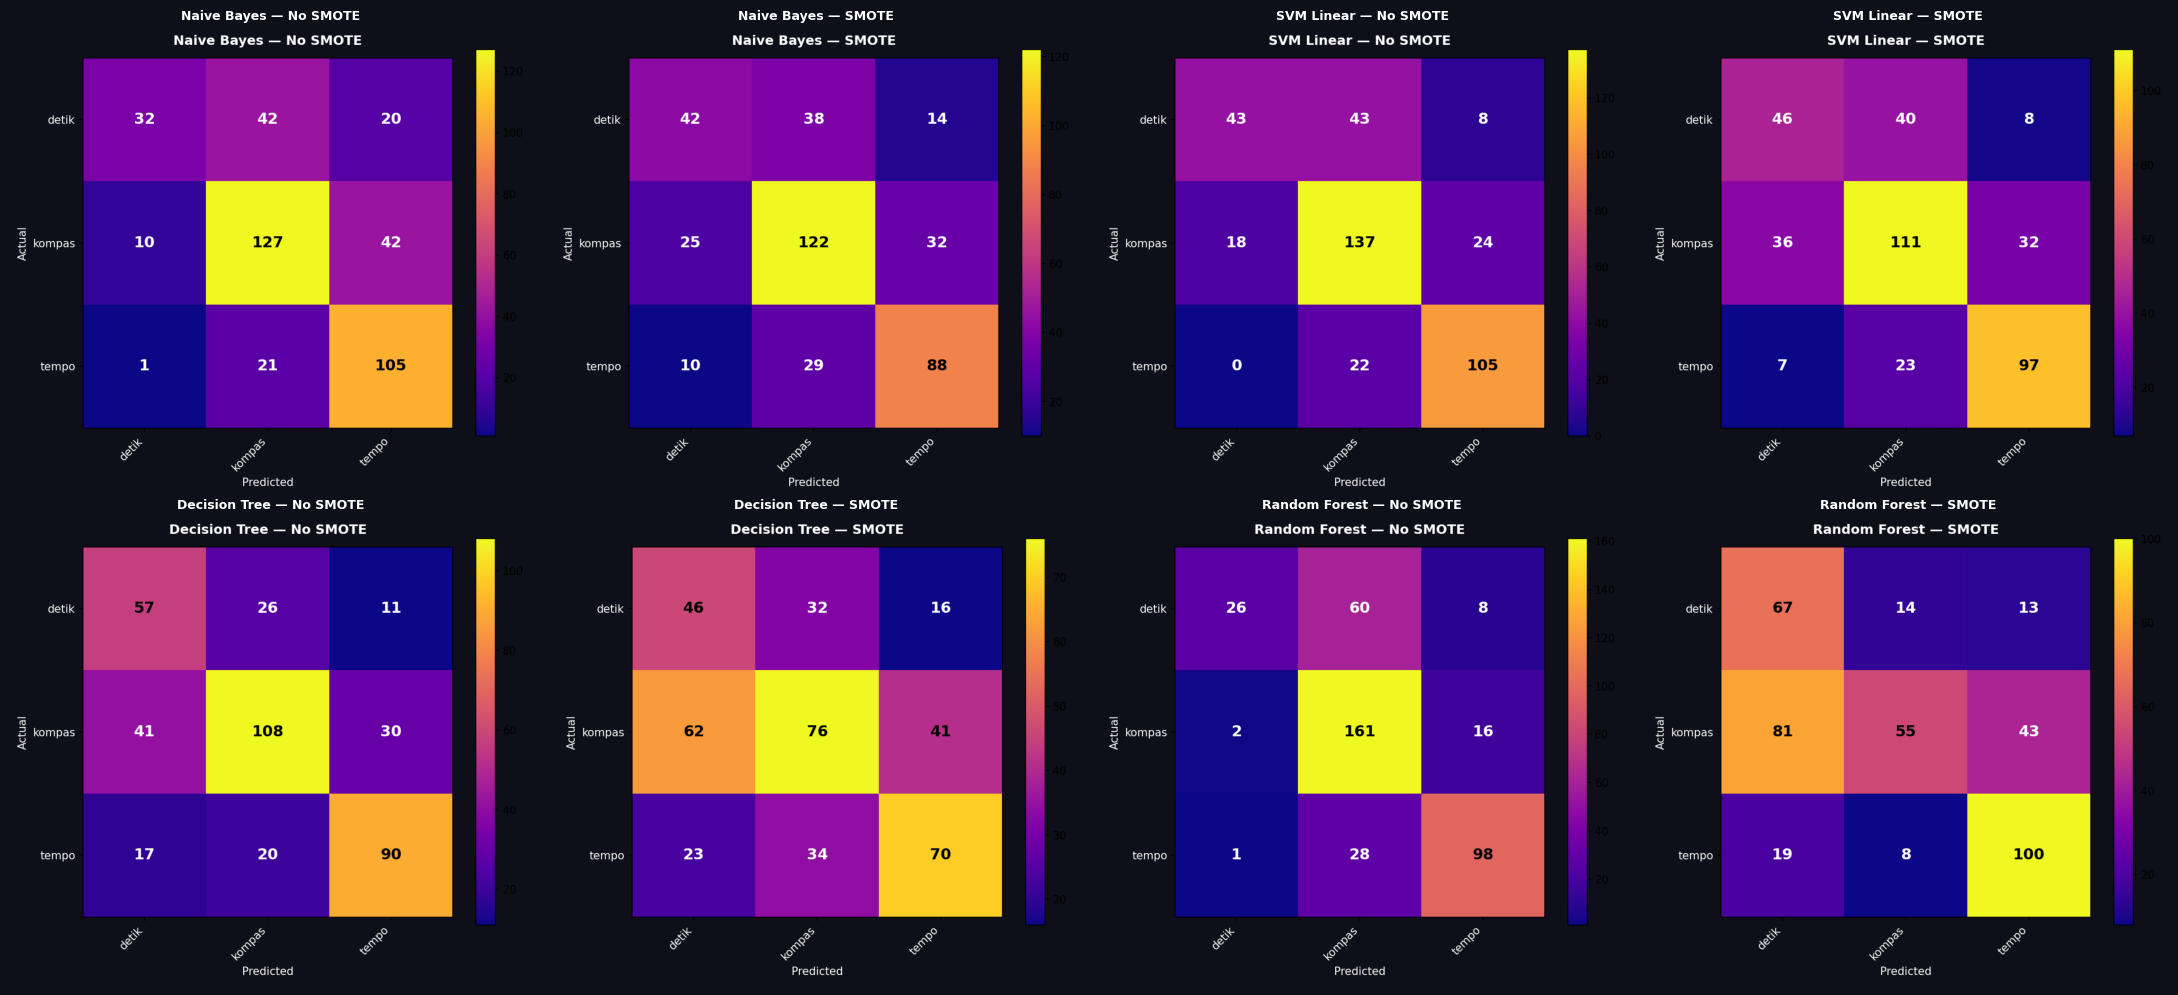

In [40]:
cm_files = [
    ('cm_nb_nosmote.png',  'Naive Bayes — No SMOTE'),
    ('cm_nb_smote.png',    'Naive Bayes — SMOTE'),
    ('cm_svm_nosmote.png', 'SVM Linear — No SMOTE'),
    ('cm_svm_smote.png',   'SVM Linear — SMOTE'),
    ('cm_dt_nosmote.png',  'Decision Tree — No SMOTE'),
    ('cm_dt_smote.png',    'Decision Tree — SMOTE'),
    ('cm_rf_nosmote.png',  'Random Forest — No SMOTE'),
    ('cm_rf_smote.png',    'Random Forest — SMOTE'),
]

fig, axes = plt.subplots(2, 4, figsize=(22, 10))
fig.patch.set_facecolor('#0f0f1a')
for ax, (fname, title) in zip(axes.flat, cm_files):
    fpath = RESULTS_DIR / fname
    if fpath.exists():
        ax.imshow(mpimg.imread(fpath))
        ax.set_title(title, fontsize=9, fontweight='bold', color='white')
    else:
        ax.set_title(f'{fname} not found', color='red')
    ax.axis('off')
plt.tight_layout()
plt.show()

---
## 18. IndoBERT Learning Curve

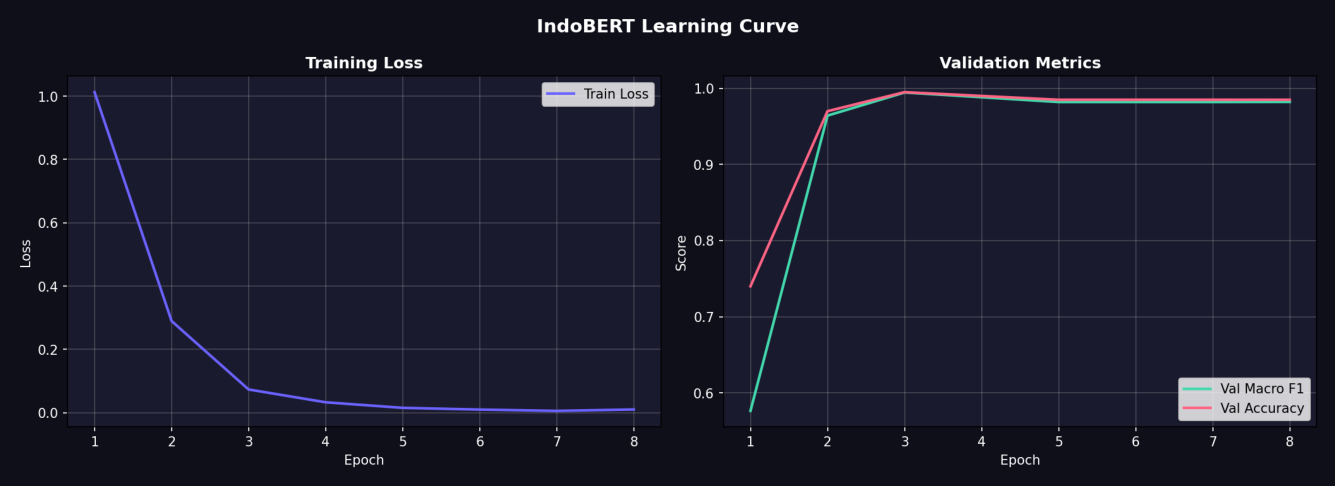

In [41]:
lc_path = RESULTS_DIR / 'indobert_learning_curve.png'
if lc_path.exists():
    img = mpimg.imread(lc_path)
    plt.figure(figsize=(14, 5))
    plt.imshow(img)
    plt.axis('off')
    plt.tight_layout()
    plt.show()
else:
    print('Learning curve belum tersedia. Jalankan run_pipeline.py.')

---
## 19. Confusion Matrix — IndoBERT

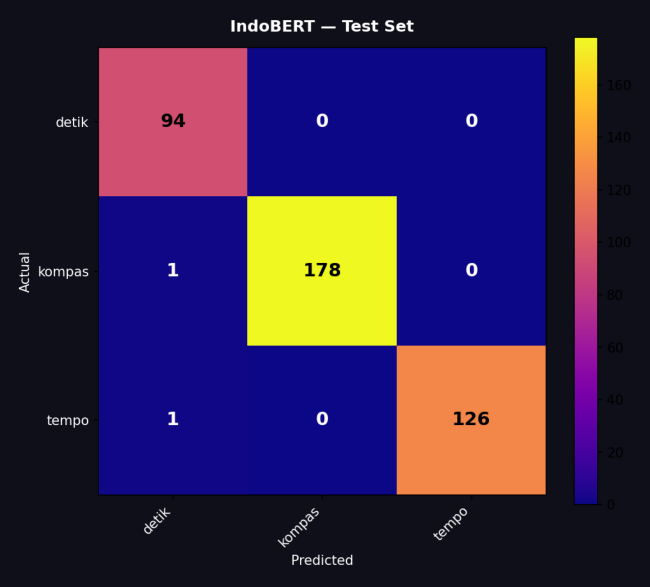

In [42]:
cm_bert_path = RESULTS_DIR / 'cm_indobert.png'
if cm_bert_path.exists():
    img = mpimg.imread(cm_bert_path)
    plt.figure(figsize=(7, 6))
    plt.imshow(img)
    plt.axis('off')
    plt.tight_layout()
    plt.show()
else:
    print('Confusion matrix IndoBERT belum tersedia.')

---
## 20. Perbandingan Final Semua Model

,Model,SMOTE,Test_F1,Test_Acc,CV_F1,CV_std,Train_Time_s
0,IndoBERT,No,0.9942,0.9950,NaN,NaN,200.75
1,SVM Linear,No,0.6898,0.7125,0.6962,0.0261,0.04
2,Random Forest,No,0.6541,0.7125,0.6495,0.0242,0.42
3,Decision Tree,No,0.6306,0.6375,0.5960,0.0292,0.53
4,Naive Bayes,No,0.6233,0.6600,0.6317,0.0462,0.00
5,SVM Linear,Yes,0.6222,0.6350,NaN,NaN,0.07
6,Naive Bayes,Yes,0.6095,0.6300,NaN,NaN,0.00
7,Random Forest,Yes,0.5499,0.5550,NaN,NaN,0.38
8,Decision Tree,Yes,0.4779,0.4800,NaN,NaN,0.32


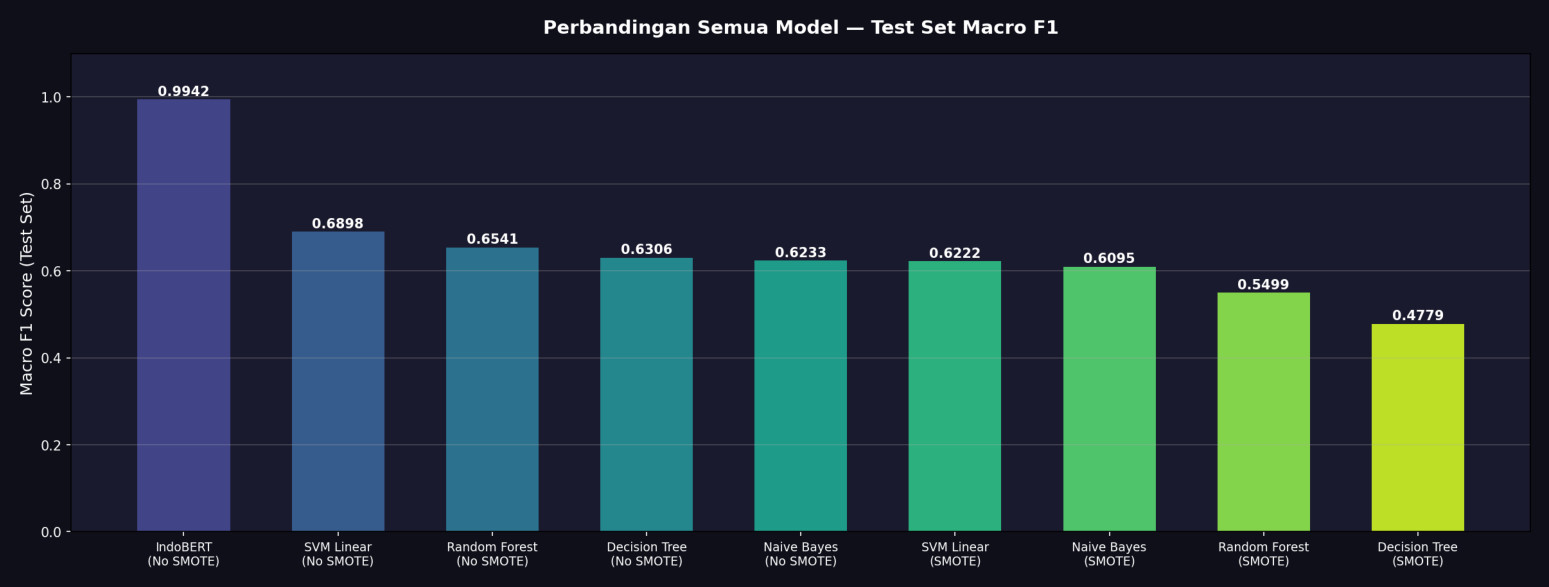

Model terbaik : IndoBERT (SMOTE: No)
Test Macro F1 : 0.9942
Test Accuracy : 0.9950


In [44]:
final_df = pd.read_csv(RESULTS_DIR / 'final_results.csv')
display(final_df.sort_values('Test_F1', ascending=False))

img = mpimg.imread(RESULTS_DIR / 'final_comparison.png')
plt.figure(figsize=(16, 6))
plt.imshow(img)
plt.axis('off')
plt.tight_layout()
plt.show()

best = final_df.sort_values('Test_F1', ascending=False).iloc[0]
print(f'Model terbaik : {best["Model"]} (SMOTE: {best["SMOTE"]})')
print(f'Test Macro F1 : {best["Test_F1"]:.4f}')
print(f'Test Accuracy : {best["Test_Acc"]:.4f}')